In [16]:
get_ipython().system('pip install -q timm albumentations pydicom')

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import pydicom
import albumentations as A
import timm

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cpu
CUDA: False


In [18]:
def find_data():
    base = Path('/kaggle/input')
    # Check all subdirectories for train.csv
    for folder in base.rglob('*'):
        if folder.is_dir() and (folder / 'train.csv').exists():
            print(f"✅ Data found: {folder}")
            return folder
    print("❌ Data not found!")
    return None

DATA_DIR = find_data()

✅ Data found: /kaggle/input/competitions/rsna-knee-abnormality-detection


In [19]:
TARGETS = ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
           'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
           'Synovitis', "Baker's", 'Contusion', 'Fracture']

MODEL_NAME = 'efficientnet_b0'
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 1e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}, Batch: {BATCH_SIZE}, Epochs: {NUM_EPOCHS}")

Device: cpu, Batch: 16, Epochs: 3


In [20]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f"Train: {len(train_df)}, Test: {len(sample_sub)}")
train_df.head()

Train: 4407, Test: 3


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


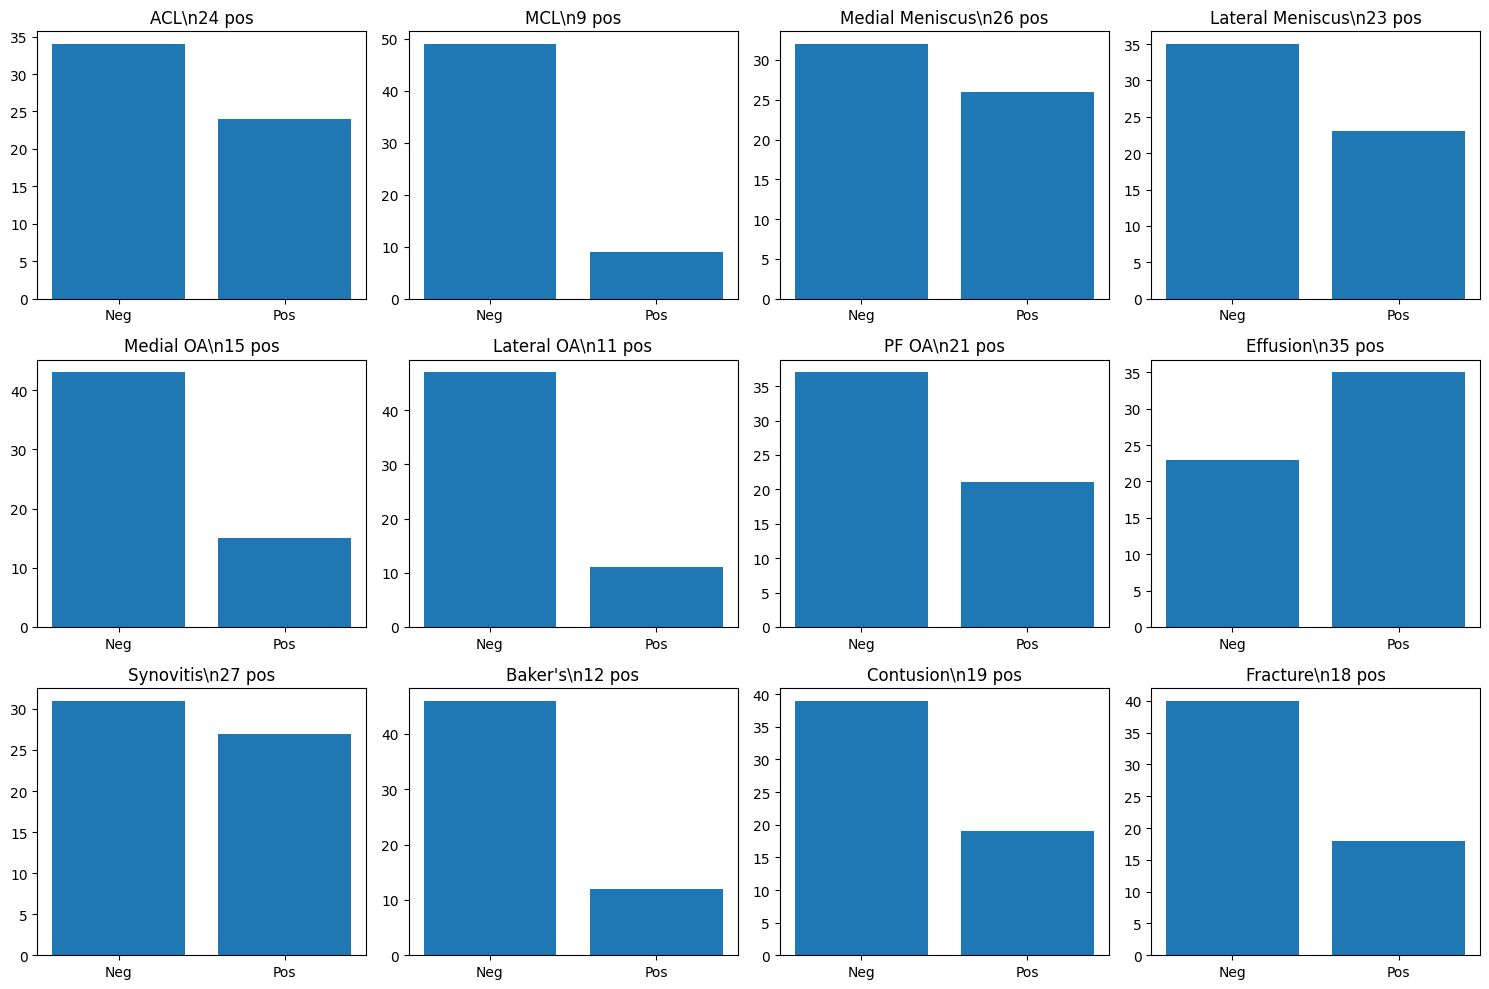

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, target in enumerate(TARGETS):
    counts = train_df[target].value_counts()
    axes[i].bar(['Neg', 'Pos'], [counts.get(0,0), counts.get(1,0)])
    axes[i].set_title(f"{target}\\n{counts.get(1,0)} pos")

plt.tight_layout()
plt.show()

In [22]:
class KneeDataset(Dataset):
    def __init__(self, df, image_dir, targets, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.targets = targets
        self.transform = transform
        self.is_test = is_test
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        study_id = row['StudyInstanceUID']
        
        # Simple approach: use first DICOM from study
        # Adjust based on actual folder structure
        try:
            study_folder = self.image_dir / str(study_id)
            if study_folder.exists():
                dicom_files = list(study_folder.glob('*.dcm'))
                if dicom_files:
                    dicom = pydicom.dcmread(str(dicom_files[0]))
                    image = dicom.pixel_array
                else:
                    image = np.zeros((256, 256), dtype=np.uint8)
            else:
                image = np.zeros((256, 256), dtype=np.uint8)
            
            # Normalize
            image = image.astype(np.float32)
            if image.max() > 0:
                image = (image - image.min()) / (image.max() - image.min())
            image = (image * 255).astype(np.uint8)
            
            # Convert to RGB
            if len(image.shape) == 2:
                image = np.stack([image] * 3, axis=-1)
                
        except Exception as e:
            image = np.zeros((256, 256, 3), dtype=np.uint8)
        
        # Transform
        if self.transform:
            image = self.transform(image=image)['image']
        
        # To tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        
        if self.is_test:
            return {'image': image, 'study_id': study_id}
        
        labels = torch.tensor(row[self.targets].values.astype(np.float32))
        return {'image': image, 'labels': labels}

print("✓ Dataset class defined")

✓ Dataset class defined


In [23]:
def get_train_transforms(size=224):
    return A.Compose([
        A.Resize(size, size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def get_valid_transforms(size=224):
    return A.Compose([
        A.Resize(size, size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

print("✓ Transforms defined")

✓ Transforms defined


In [24]:
class KneeClassifier(nn.Module):
    def __init__(self, model_name='efficientnet_b0', num_classes=12):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, 
                                         num_classes=0, global_pool='')
        
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            features = self.backbone(dummy)
            num_features = features.shape[1]
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

model = KneeClassifier(MODEL_NAME, len(TARGETS)).to(DEVICE)
print(f"✓ Model created: {sum(p.numel() for p in model.parameters()):,} params")

✓ Model created: 4,022,920 params


In [25]:
def compute_auc(y_true, y_pred):
    aucs = []
    for i in range(y_true.shape[1]):
        try:
            aucs.append(roc_auc_score(y_true[:, i], y_pred[:, i]))
        except:
            aucs.append(0.5)
    return np.mean(aucs)

def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='Training'):
        images, labels = batch['image'].to(DEVICE), batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        
        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    
    return total_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            images, labels = batch['image'].to(DEVICE), batch['labels'].to(DEVICE)
            
            with autocast():
                logits = model(images)
                loss = criterion(logits, labels)
            
            preds = torch.sigmoid(logits)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            total_loss += loss.item()
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    auc = compute_auc(all_labels, all_preds)
    
    return total_loss / len(loader), auc

print("✓ Training functions defined")

✓ Training functions defined


In [26]:
train_img_dir = DATA_DIR / 'train_series'
test_img_dir = DATA_DIR / 'test_series'

if not train_img_dir.exists():
    train_img_dir = DATA_DIR / 'train'
if not test_img_dir.exists():
    test_img_dir = DATA_DIR / 'test'

print(f"Train images: {train_img_dir}")
print(f"Test images: {test_img_dir}")

train_df_split, val_df_split = train_test_split(train_df, test_size=0.2, random_state=SEED)
print(f"Train: {len(train_df_split)}, Val: {len(val_df_split)}")

train_dataset = KneeDataset(train_df_split, train_img_dir, TARGETS, get_train_transforms(IMAGE_SIZE))
val_dataset = KneeDataset(val_df_split, train_img_dir, TARGETS, get_valid_transforms(IMAGE_SIZE))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train images: /kaggle/input/competitions/rsna-knee-abnormality-detection/train_series
Test images: /kaggle/input/competitions/rsna-knee-abnormality-detection/test_series
Train: 3525, Val: 882
Train batches: 221, Val batches: 56


In [27]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
scaler = GradScaler()

best_auc = 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print("\\nStarting training...\\n")
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_auc = validate(model, val_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")
    
    scheduler.step(val_auc)
    
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ Saved best model (AUC: {best_auc:.4f})")
    print()

print(f"Training complete! Best AUC: {best_auc:.4f}")

\nStarting training...\n
Epoch 1/3
--------------------------------------------------


Training:   0%|          | 0/221 [00:00<?, ?it/s]

Validation:   0%|          | 0/56 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c4b2155db20>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c4b2155db20>    self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        if w.is_alive():
self._shutdown_workers()  
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): ^
^ ^ ^^  ^ ^^  ^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
^ ^^ ^ ^
   File "/usr/lib/py

Train Loss: nan
Val Loss: nan, Val AUC: 0.5000
✓ Saved best model (AUC: 0.5000)

Epoch 2/3
--------------------------------------------------


...

Validation:   0%|          | 0/56 [00:00<?, ?it/s]

Train Loss: nan
Val Loss: nan, Val AUC: 0.5000

Epoch 3/3
--------------------------------------------------


Training:   0%|          | 0/221 [00:00<?, ?it/s]

Validation:   0%|          | 0/56 [00:00<?, ?it/s]

Train Loss: nan
Val Loss: nan, Val AUC: 0.5000

Training complete! Best AUC: 0.5000


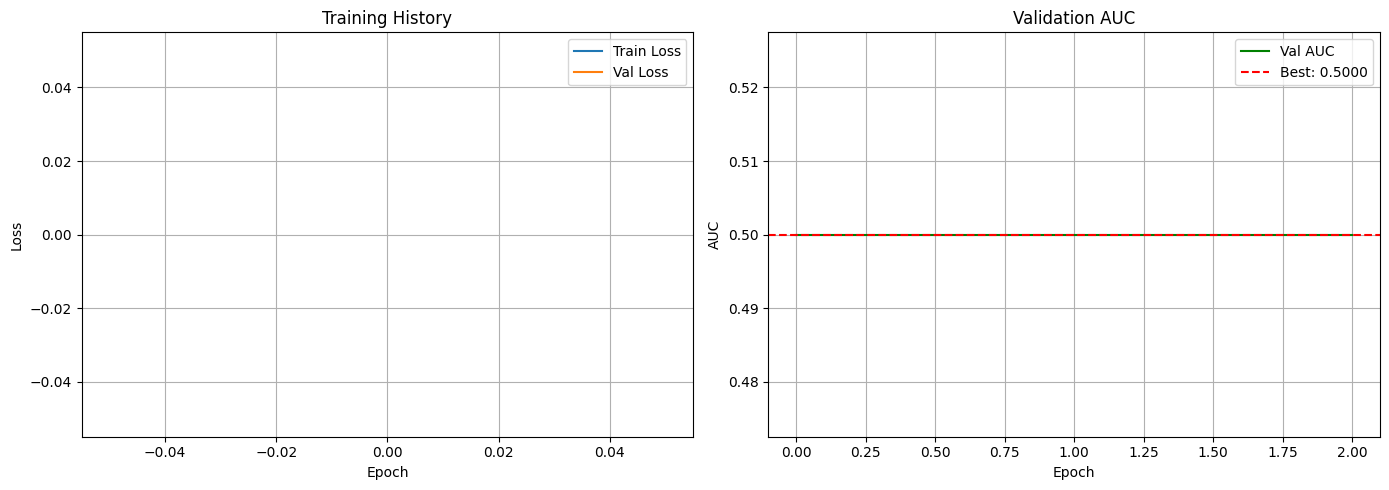

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training History')
ax1.legend()
ax1.grid(True)

ax2.plot(history['val_auc'], label='Val AUC', color='green')
ax2.axhline(y=best_auc, color='r', linestyle='--', label=f'Best: {best_auc:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.set_title('Validation AUC')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [29]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

print("Generating predictions...")

test_dataset = KneeDataset(sample_sub, test_img_dir, TARGETS, get_valid_transforms(IMAGE_SIZE), is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

all_preds = []
all_study_ids = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Inference'):
        images = batch['image'].to(DEVICE)
        study_ids = batch['study_id']
        
        with autocast():
            logits = model(images)
            preds = torch.sigmoid(logits)
        
        all_preds.append(preds.cpu().numpy())
        all_study_ids.extend(study_ids)

all_preds = np.concatenate(all_preds)

submission = pd.DataFrame({'StudyInstanceUID': all_study_ids})
for i, target in enumerate(TARGETS):
    submission[target] = all_preds[:, i]

submission.to_csv('submission.csv', index=False)
print("\\n✓ Submission saved!")
print(f"Shape: {submission.shape}")
submission.head()

Generating predictions...


Inference:   0%|          | 0/1 [00:00<?, ?it/s]

\n✓ Submission saved!
Shape: (3, 13)


Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run


In [ ]:
print("=" * 60)
print("RSNA Knee Abnormality Detection - Complete!")
print("=" * 60)
print(f"\\nBest Validation AUC: {best_auc:.4f}")
print(f"Model: {MODEL_NAME}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"\\nSubmission: submission.csv ({submission.shape})")
print("\\nNext steps:")
print("1. Submit submission.csv to competition")
print("2. Try larger model (efficientnet_b1, efficientnet_b2)")
print("3. Increase epochs (5-10)")
print("4. Use cross-validation")
print("5. Ensemble multiple models")
print("=" * 60)

RSNA Knee Abnormality Detection - Complete!
\nBest Validation AUC: 0.5000
Model: efficientnet_b0
Epochs: 3
\nSubmission: submission.csv ((3, 13))
\nNext steps:
1. Submit submission.csv to competition
2. Try larger model (efficientnet_b1, efficientnet_b2)
3. Increase epochs (5-10)
4. Use cross-validation
5. Ensemble multiple models
